# t-SNE

- 비선형 차원 축소 기법으로 고차원의 데이터를 국소 구조를 보존하면서 2차원 또는 3차원 시각화 하기 위해 주로 사용
- 고차원의 경우에는 거리 기반의 유사도 (가우시안 분포)
- 저차원의 경우에는 확률적으로 비슷하게 재현 (t-분포를 이용한 계산)
    - t-분포를 사용하는 이유는 멀리 떨어진 점간의 거리 차이를 완화시키기 위한 방법


### 거리 값들의 의미
- 유클리드 거리 (euclidean) -> 기본적인 거리방식 (직선거리)
- 맨헤튼 거리 (manhattan) -> 직각 축 기반 거리
- 체비쇼프 거리 (chebyshev) -> 최대의 축 차이 기반
- 코사인 거리 (cosine) -> 벡터 방향 기반
- 마할라노비스 거리(mahalanobis) -> 변수 간 상관 반영
- 해밍 거리 (hamming) -> 이진 데이터 전용

- 매개변수
    - n_compoents
        - 기본값 : 2
        - 축소할 차원의 개수
    - perplexity
        - 기본값 : 30
        - 이웃의 수 제어 (군집 크기 민감)
        - 보통 5-50 정도의 값
        - 값이 작은 경우는 작은 구조, 큰 경우에는 전체 구조
        - 일반적으로는 샘플의 개수 / 3
        - 너무 큰 값을 생성하면 전체를 포괄하는 형태가 될 수 있음
    - early_exggerarion
        - 기본값 : 12
        - 초기 학습에서 군집 간의 거리를 지정 (분리 촉진)
    - learning_rate
        - 기본값 : 'auto'
        - 학습의 속도
        - 너무 작게 지정하면 수렴 느려짐
        - 너무 크게 하는 경우에는 군집이 왜곡
        - 100~1000 정도의 값을 사용
    - max_iter
        - 기본값 : 1000
        - 전체 학습 반복 횟수
    - n_iter_without_progress
        - 기본값 : 300
        - 개선이 없을때 조기 종료 기준
    - init
        - 기본값 : 'pca'
        - 초기 좌표를 설정하는 방법
        - random을 사용 시 좌표를 무작위로 선택
    - metric
        - 기본값 : 'euclidean'
        - 거리 계산 방법
    - method
        - 기본값 : 'barnes_hut'
        - 기본값을 사용시 빠른 속도로 계산
        - 'exact'는 정확하지만 시간은 증가
    - angle
        - 기본값 : 0.5
        - barnes_hut 근사 정확도를 제어
        - 작을수록 정확하고 느림
- 속성
    - embedding_
        - 변환된 저차원 데이터 변환
    - kl_divergence_
        - 최종 KL 발산 값 봔환 (작을수록 원래의 구조와 유사)
- 메서드
    - fit()
        - 모델에 데이터를 학습
    - transform()
        - 데이터를 저차원 변환
    - fit_transform()
        - 데이터를 학습하고 저차원 데이터로 변환

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

In [2]:
# 데이터셋 로드
digits = load_digits()

In [ ]:
digits

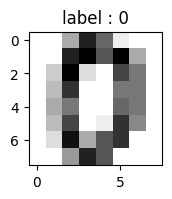

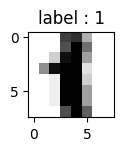

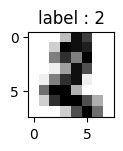

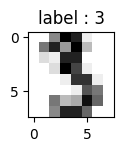

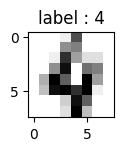

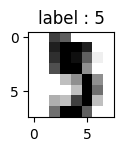

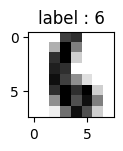

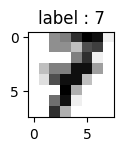

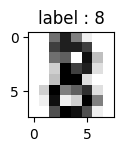

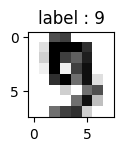

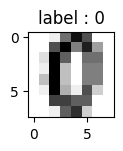

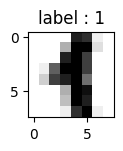

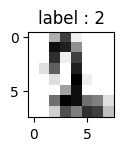

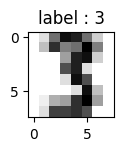

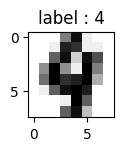

In [8]:
plt.figure(figsize=(10, 6))

for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(digits.images[i], cmap='gray_r')
    plt.title(f'label : {digits.target[i]}')
    plt.show('off')
    
plt.show()

In [11]:
# 데이터를 스케일링
X = StandardScaler().fit_transform(digits['data'])
Y = digits['target']

In [12]:
# 차원 축소 class 생성
tsen = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate='auto',
    random_state=42,
    n_jobs=-1   #멀티코어 전체 사용
)
X_tsne = tsen.fit_transform(X)

In [13]:
X.shape

(1797, 64)

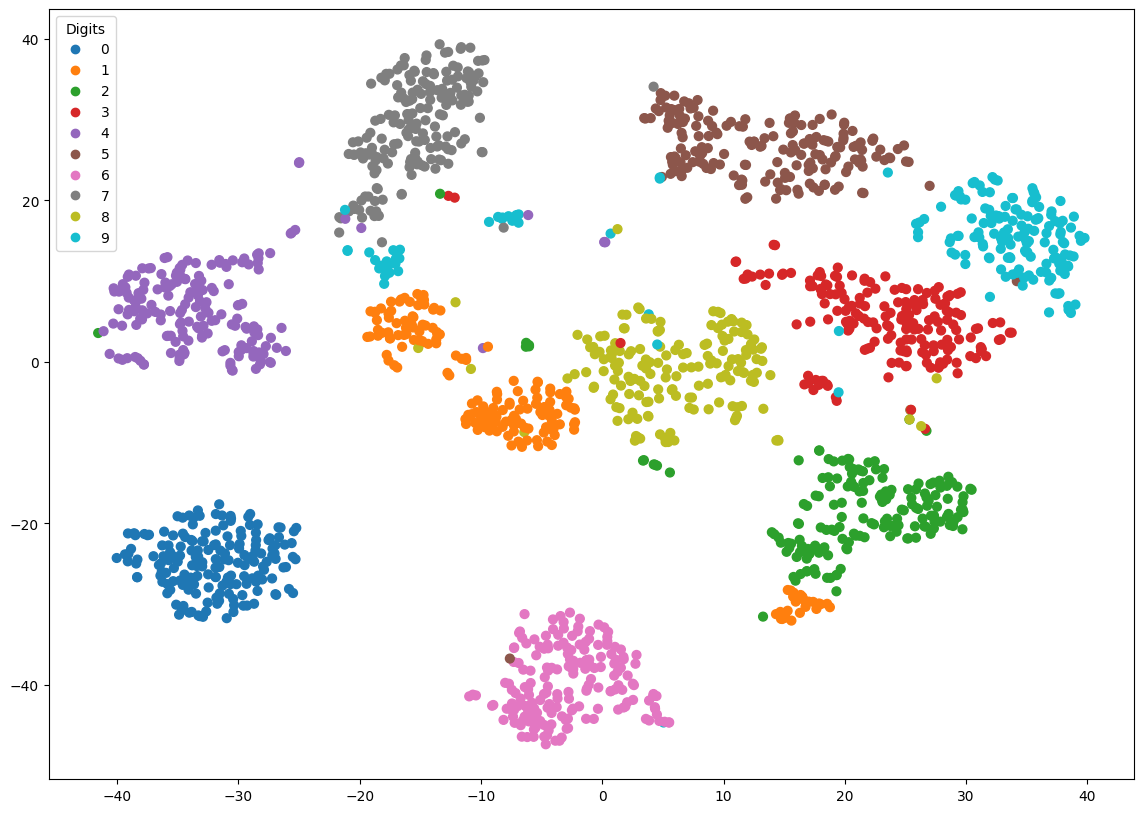

In [14]:
# 64차원의 데이터를 2차원으로 변경하고 데이터의 분류를 그래프로 시각화
plt.figure(figsize=(14, 10))
sc = plt.scatter(X_tsne[:, 0], X_tsne[:, 1],
                c = Y, cmap='tab10', s=40)
plt.legend(*sc.legend_elements(), title='Digits')
plt.show()

In [16]:
print("KL divergence :", round(tsen.kl_divergence_, 4))
print('Iteration : ', tsen.n_iter_)

KL divergence : 0.801
Iteration :  999


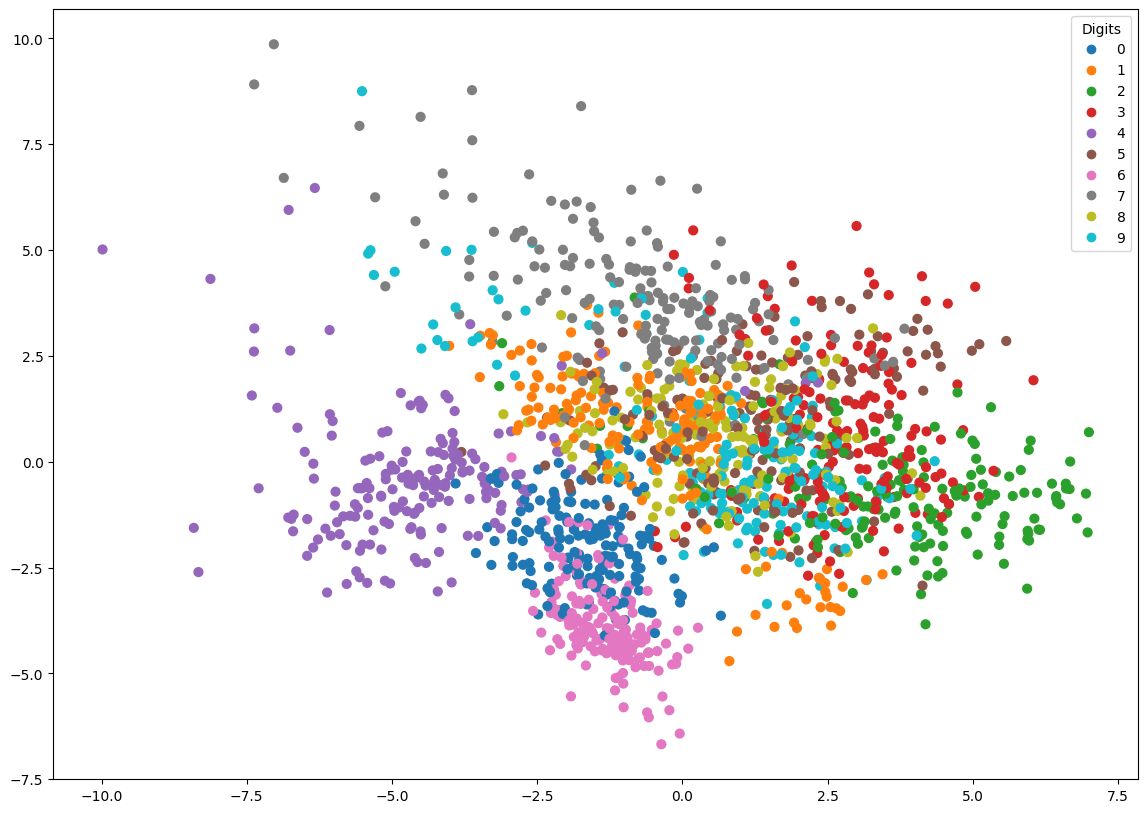

In [17]:
# PCA로 2차원 데이터 시각화
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 시각화
plt.figure(figsize=(14, 10))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=Y,
            cmap='tab10', s=40)
plt.legend(*sc.legend_elements(), title='Digits')
plt.show()

In [18]:
from sklearn.datasets import make_moons

In [19]:
# 반월 모양의데이터셋을 생성
X, Y = make_moons(n_samples=1000, noise=0.1, random_state=42)
X_std = StandardScaler().fit_transform(X)

In [20]:
X_std.shape

(1000, 2)

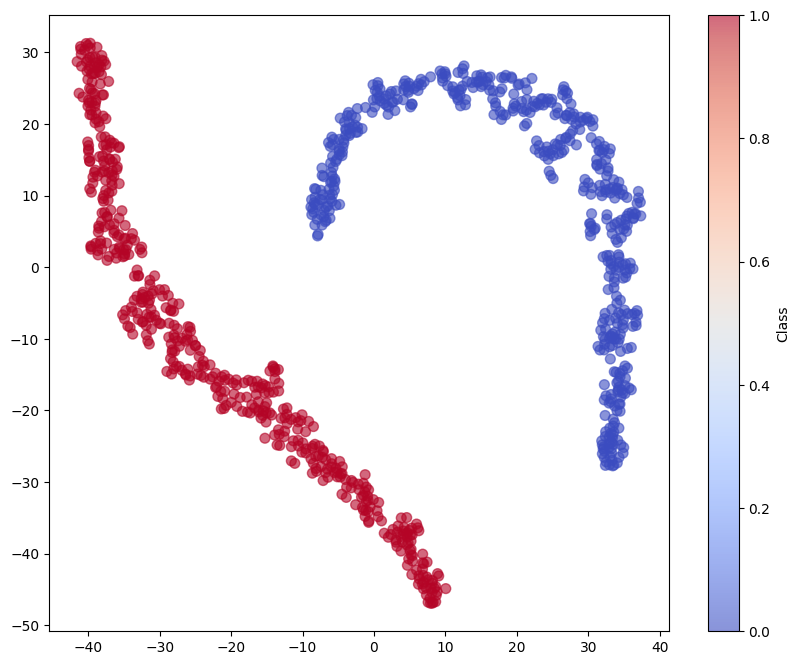

In [22]:
# T_SNE을 적용해서 2차원 데이터로 구성
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200,
            random_state=42)
X_tsne = tsne.fit_transform(X_std)
plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=Y,
            cmap='coolwarm', s=50, alpha=0.6)

plt.colorbar(label='Class')
plt.show()

In [24]:
# bodyPerfermance 데이터를 이용하여 tsne 차원축소
import pandas as pd
from sklearn.preprocessing import LabelEncoder

In [25]:
body = pd.read_csv("../data/bodyPerformance.csv")

In [26]:
# dtypes가 'object'인 컬럼을 모두 선택해서 LaabelEncoder로 변환

# dtypes가 'object;인 컬럼의 목록 확인
obj_list = body.select_dtypes('object').columns.tolist()
obj_list

['gender', 'class']

In [27]:
for col in obj_list:
    le = LabelEncoder()
    body[col] = le.fit_transform(body[col].values)

body.head()

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class
0,27.0,1,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,2
1,25.0,1,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,0
2,31.0,1,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,2
3,32.0,1,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,1
4,28.0,1,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,1


In [29]:
# 고차원 데이터에서는 PCA를 통해서 차원 축소(30-50차원)를 1차적으로 진행한뒤 t-SNE를 이용하여 2차 작업 -> t-sne의 앉어성과 속도 향상
X = body.drop('class', axis=1).values
Y = body['class'].values
# X를 스케일링
X_std = StandardScaler().fit_transform(X)

# PCA를 통해서 1차 차원 축소
X_pca = PCA(
    n_components= min(30, X_std.shape[1]),
    random_state=42
).fit_transform(X_std)

In [30]:
X_pca.shape

(13393, 11)

In [31]:
# t-SNE를 이용하여 2차 차원 축소
tsne = TSNE(
    n_components=2,
    perplexity=40,
    random_state=42,
)

X_tsne = tsne.fit_transform(X_pca)

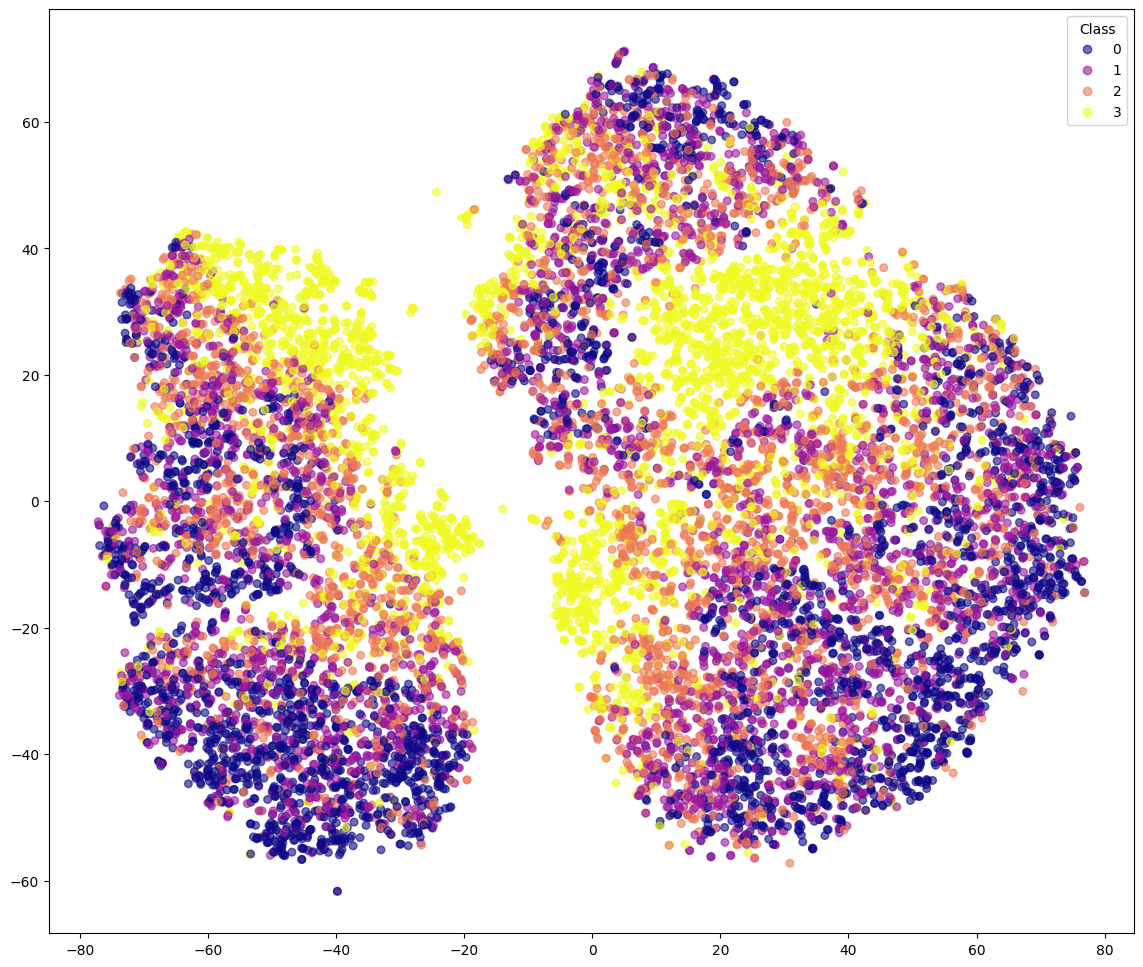

In [32]:
# 클래스를 기준으로 데이터를 시각화
plt.figure(figsize=(14, 12))
sc = plt.scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=Y, cmap='plasma', s = 30, alpha=0.6
)
plt.legend(*sc.legend_elements(), title='Class')
plt.show()